In [1]:
import os
import re
import pandas as pd

# 1) Load the embeddings CSV from project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
csv_filename = 'embeddings_GSE42861_mult2_nyears10_seed42.csv'
csv_path = os.path.join(project_root, csv_filename)

if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"CSV file not found at: {csv_path}")

# Use index column if present (first column often is an index for embeddings)
# We'll try to infer: if the first column has non-numeric values typical of sample IDs, set it as index
_df = pd.read_csv(csv_path)
first_col_name = str(_df.columns[0])
if first_col_name.lower() in {'index', 'id', 'sample_id'} or _df[first_col_name].dtype == 'object':
    df = pd.read_csv(csv_path, index_col=0)
else:
    df = _df

# 2) Normalize index to pure GSM accession (GSM\d+) and keep rows with a GSM
# Convert index to string in case it's not
df.index = df.index.map(str)
# Extract GSM ids from index
gsm_index = df.index.to_series().str.extract(r"(GSM\d+)", expand=False)
# Keep only rows that have a GSM and set it as the index
df = df.loc[gsm_index.notna()].copy()
df.index = gsm_index[gsm_index.notna()]
# Use the normalized dataframe for downstream steps
filtered_df = df

# Print head of the normalized dataframe
print("Filtered dataframe head (index normalized to GSM):")
display(filtered_df.head())

# 3) Load metadata via biolearn for the accession number parsed from the filename
# We assume the filename contains an accession like GSE12345; extract it.
accession_match = re.search(r"(GSE\d+)", csv_filename, flags=re.IGNORECASE)
accession = accession_match.group(1).upper() if accession_match else None

print("\nAccession parsed from filename:", accession)

# 3) Load metadata via biolearn using simulacra.utils helpers
from simulacra.utils import load_acc

if accession is None:
    print("\nCould not parse a GSE accession from the filename; cannot load metadata.")
else:
    try:
        data = load_acc(accession)
        metadata_df = data.metadata
        print("\nBiolearn metadata (head):")
        try:
            display(metadata_df.head())
        except Exception:
            # Fallback printing if display is unavailable
            print(metadata_df.head())
        print("Metadata shape:", getattr(metadata_df, 'shape', None))
    except Exception as e:
        print("\nFailed to load metadata via biolearn/DataLibrary.")
        print("Reason:", repr(e))



Filtered dataframe head (index normalized to GSM):


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
id,,,,,,,,,,,,,,,,,,,,,
GSM1051881,-0.001305,0.000200,0.001953,-0.002734,0.000159,0.001963,-0.000451,-0.005499,0.002583,-0.003466,...,0.001220,-0.001565,-0.005460,-0.002010,-0.004003,0.000767,0.000756,-0.003183,0.001178,-0.002373
GSM1051977,0.000590,-0.001857,-0.002502,0.002780,-0.001102,-0.001300,-0.001350,-0.001323,-0.004603,0.001543,...,-0.000943,0.004626,-0.001879,-0.000146,0.002117,-0.001068,0.001165,-0.001526,0.000915,0.000664
GSM1052156,0.000802,0.004568,0.006876,0.001612,-0.002390,0.007284,-0.002453,-0.001633,-0.000554,-0.005257,...,-0.003316,0.002482,-0.001748,0.001319,-0.003379,-0.003346,-0.000742,0.000892,-0.001373,-0.003123
GSM1051741,-0.003565,-0.002953,0.000190,-0.004830,0.000698,0.003887,-0.004089,-0.004348,0.004465,-0.001062,...,0.001848,-0.001194,0.002220,0.000575,-0.002808,0.000373,-0.001696,-0.004429,-0.000311,-0.000372
GSM1051729,0.003396,0.000118,-0.000663,0.006748,-0.002380,0.002448,-0.000839,-0.004645,-0.002241,-0.002708,...,-0.001094,-0.001565,0.001197,-0.001617,0.000472,0.005212,-0.000733,-0.000215,0.001592,0.002087



Accession parsed from filename: GSE42861

Biolearn metadata (head):


,disease,age,sex,smoking
id,,,,
GSM1051525,rheumatoid arthritis,67.0,1,current
GSM1051526,rheumatoid arthritis,49.0,1,current
GSM1051527,rheumatoid arthritis,53.0,1,ex
GSM1051528,rheumatoid arthritis,62.0,1,current
GSM1051529,rheumatoid arthritis,33.0,1,never


Metadata shape: (689, 4)


In [2]:
import re
import pandas as pd

# Validate prerequisites
if 'filtered_df' not in globals() or 'metadata_df' not in globals():
    raise RuntimeError("Required variables not found. Ensure the first cell was executed (defines 'filtered_df' and 'metadata_df').")

# Embeddings index is already normalized to GSM in the first cell
# Ensure no missing GSMs remain
if pd.Series(filtered_df.index.astype(str)).str.match(r"^GSM\d+$").pipe(lambda s: ~s).any():
    raise ValueError("Embeddings index must be normalized to GSM before merging.")

# Prepare metadata index to be GSM-based
mdf = metadata_df.copy()
if not mdf.index.astype(str).str.contains(r"^GSM\d+$", case=False, regex=True).all():
    # Try common columns that may hold GSM accessions
    candidate_cols = [c for c in mdf.columns if str(c).lower() in {"gsm", "geo_accession"}]
    if candidate_cols:
        mdf = mdf.set_index(candidate_cols[0])
    else:
        # Try to extract GSM from any string-like column heuristically
        found_index = None
        for c in mdf.columns:
            if pd.api.types.is_string_dtype(mdf[c]):
                gsm_series = mdf[c].astype(str).str.extract(r"(GSM\d+)", expand=False)
                if gsm_series.notna().all():
                    mdf = mdf.set_index(gsm_series)
                    found_index = c
                    break
        if found_index is None:
            raise ValueError("Could not identify a GSM-based index in metadata. Expected index or a column like 'gsm' or 'geo_accession'.")

# Locate the disease column (case-insensitive match on name 'disease')
disease_col_candidates = [c for c in mdf.columns if str(c).lower() == 'disease']
if not disease_col_candidates:
    raise ValueError("'disease' column not found in metadata.")
disease_col = disease_col_candidates[0]

# Build aligned disease series for the filtered embeddings using GSM index directly
disease_by_gsm = mdf[disease_col]
disease_for_emb = pd.Series(filtered_df.index.astype(str), index=filtered_df.index).map(disease_by_gsm)

# Create merged dataframe with disease as the first non-index column
merged_df = filtered_df.copy()
merged_df.insert(0, 'disease', disease_for_emb)

# Display head
print("Merged dataframe head (with 'disease' as first column):")
try:
    display(merged_df.head())
except Exception:
    print(merged_df.head())



Merged dataframe head (with 'disease' as first column):


,disease,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
id,,,,,,,,,,,,,,,,,,,,,
GSM1051881,rheumatoid arthritis,-0.001305,0.000200,0.001953,-0.002734,0.000159,0.001963,-0.000451,-0.005499,0.002583,...,0.001220,-0.001565,-0.005460,-0.002010,-0.004003,0.000767,0.000756,-0.003183,0.001178,-0.002373
GSM1051977,rheumatoid arthritis,0.000590,-0.001857,-0.002502,0.002780,-0.001102,-0.001300,-0.001350,-0.001323,-0.004603,...,-0.000943,0.004626,-0.001879,-0.000146,0.002117,-0.001068,0.001165,-0.001526,0.000915,0.000664
GSM1052156,rheumatoid arthritis,0.000802,0.004568,0.006876,0.001612,-0.002390,0.007284,-0.002453,-0.001633,-0.000554,...,-0.003316,0.002482,-0.001748,0.001319,-0.003379,-0.003346,-0.000742,0.000892,-0.001373,-0.003123
GSM1051741,rheumatoid arthritis,-0.003565,-0.002953,0.000190,-0.004830,0.000698,0.003887,-0.004089,-0.004348,0.004465,...,0.001848,-0.001194,0.002220,0.000575,-0.002808,0.000373,-0.001696,-0.004429,-0.000311,-0.000372
GSM1051729,rheumatoid arthritis,0.003396,0.000118,-0.000663,0.006748,-0.002380,0.002448,-0.000839,-0.004645,-0.002241,...,-0.001094,-0.001565,0.001197,-0.001617,0.000472,0.005212,-0.000733,-0.000215,0.001592,0.002087


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from typing import Dict, Any, Tuple

# Validate prerequisites
if 'merged_df' not in globals():
    raise RuntimeError("'merged_df' not found. Ensure previous cells were executed.")


def train_ridge_classifier(
    df: 'pd.DataFrame',
    target_col: str = 'disease',
    test_size: float = 0.2,
    random_state: int = 42,
    stratify: bool = True,
) -> Tuple[Pipeline, Dict[str, Any]]:
    """Split, train and evaluate a Ridge classifier on the provided dataframe.

    Returns the fitted pipeline and a metrics dict with accuracy, macro F1, and the full report.
    """
    import pandas as pd

    y_local = df[target_col]
    X_local = df.drop(columns=[target_col])

    if X_local.isna().any().any() or y_local.isna().any():
        mask_local = (~X_local.isna().any(axis=1)) & y_local.notna()
        X_local = X_local.loc[mask_local]
        y_local = y_local.loc[mask_local]

    stratify_vals = y_local if (stratify and y_local.nunique() > 1) else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_local, y_local, test_size=test_size, random_state=random_state, stratify=stratify_vals
    )

    model = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('ridge', RidgeClassifier(random_state=random_state))
    ])
    model.fit(X_tr, y_tr)

    y_hat = model.predict(X_te)
    metrics = {
        'accuracy': accuracy_score(y_te, y_hat),
        'f1_macro': f1_score(y_te, y_hat, average='macro'),
        'report': classification_report(y_te, y_hat, output_dict=False),
        'y_true': y_te,
        'y_pred': y_hat,
    }

    print("Validation accuracy:", metrics['accuracy'])
    print("Validation macro F1:", metrics['f1_macro'])
    print("\nClassification report:\n")
    print(metrics['report'])

    return model, metrics

# Train baseline classifier on merged_df
baseline_model, baseline_metrics = train_ridge_classifier(merged_df)



Validation accuracy: 0.857487922705314
Validation macro F1: 0.649228118044087

Classification report:

                      precision    recall  f1-score   support

              Normal       0.64      0.27      0.38        67
rheumatoid arthritis       0.87      0.97      0.92       347

            accuracy                           0.86       414
           macro avg       0.76      0.62      0.65       414
        weighted avg       0.84      0.86      0.83       414



In [4]:
import pandas as pd
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata

# Validate prerequisites
if 'X_train' not in globals() or 'y_train' not in globals():
    raise RuntimeError("Training split not found. Run the previous cell first.")

# Build a single-table DataFrame for SDV with target included
train_with_target = X_train.copy()
train_with_target.insert(0, 'disease', y_train)

# Create SDV Metadata inferred from the training data
metadata = Metadata.detect_from_dataframe(
    data=train_with_target,
    table_name='embeddings_train'
)

# Fit Gaussian Copula synthesizer with KDE as default distribution
synthesizer = GaussianCopulaSynthesizer(
    metadata,
    default_distribution='gaussian_kde'
)
synthesizer.fit(train_with_target)

# Generate synthetic rows: 2x additional to get 3x total size
num_rows_real = len(train_with_target)
num_rows_synth = 2 * num_rows_real
synthetic_train = synthesizer.sample(num_rows=num_rows_synth)

# Combine real and synthetic
augmented_train = pd.concat([train_with_target, synthetic_train], axis=0, ignore_index=True)

print("Original train shape:", train_with_target.shape)
print("Synthetic rows:", synthetic_train.shape)
print("Augmented train shape:", augmented_train.shape)

# Display head of augmented training data
try:
    display(augmented_train.head())
except Exception:
    print(augmented_train.head())



C:\Users\ferdi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sdv\single_table\base.py:128: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original train shape: (1653, 513)
Synthetic rows: (3306, 513)
Augmented train shape: (4959, 513)


,disease,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,rheumatoid arthritis,-0.002477,0.003586,0.012243,-0.000533,-0.004430,0.007843,-0.006109,-0.003373,-0.001639,...,-0.000257,-0.001067,-0.000298,-0.003455,-0.005516,-0.005543,0.000220,0.002824,-0.002563,0.000242
1,rheumatoid arthritis,0.006394,-0.000444,-0.001226,0.006966,-0.002765,0.000425,0.003337,0.001329,-0.006819,...,-0.000235,0.001581,0.002133,-0.003830,0.000141,0.003038,-0.000518,0.000946,0.001316,0.000408
2,rheumatoid arthritis,-0.005281,-0.001189,0.000055,-0.009545,0.001670,0.001360,-0.003920,-0.009408,0.009124,...,-0.001043,0.000250,-0.002847,0.002873,-0.001487,-0.003244,0.002232,-0.001140,-0.005581,-0.001701
3,rheumatoid arthritis,-0.002604,0.005943,-0.002124,-0.001965,-0.000431,0.003388,0.000245,-0.002233,-0.005134,...,-0.006915,0.002561,-0.000364,0.001076,0.000784,-0.005202,0.002143,0.000434,0.001442,0.001583
4,rheumatoid arthritis,0.003255,0.003624,-0.006537,0.006363,-0.002228,-0.001518,0.003916,0.005647,-0.005919,...,-0.005102,0.008667,0.001729,0.001987,0.002010,0.000687,-0.001283,-0.003154,0.000097,-0.000038


In [10]:
# Train on augmented data using the reusable function
if 'augmented_train' not in globals():
    raise RuntimeError("'augmented_train' not found. Run the augmentation cell first.")

augmented_model, augmented_metrics = train_ridge_classifier(augmented_train)

print("\nAugmented training performance:")
print("Accuracy:", augmented_metrics['accuracy'])
print("Macro F1:", augmented_metrics['f1_macro'])



Validation accuracy: 0.8336693548387096
Validation macro F1: 0.579901597184971

Classification report:

                      precision    recall  f1-score   support

              Normal       0.55      0.16      0.25       170
rheumatoid arthritis       0.85      0.97      0.91       822

            accuracy                           0.83       992
           macro avg       0.70      0.57      0.58       992
        weighted avg       0.80      0.83      0.79       992


Augmented training performance:
Accuracy: 0.8336693548387096
Macro F1: 0.579901597184971


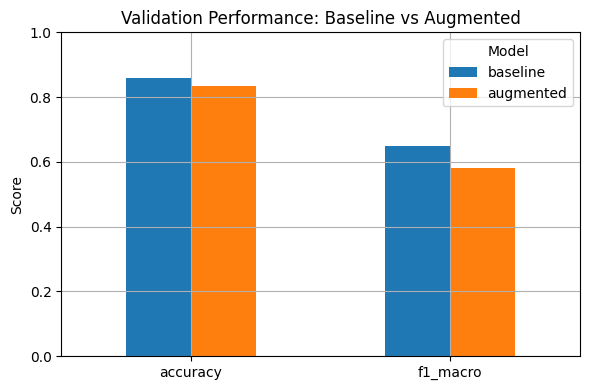

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Compare baseline vs augmented performance
if 'baseline_metrics' not in globals() or 'augmented_metrics' not in globals():
    raise RuntimeError("Missing metrics. Ensure both baseline and augmented models were trained.")

metrics_to_plot = ['accuracy', 'f1_macro']
values = pd.DataFrame({
    'baseline': [baseline_metrics[m] for m in metrics_to_plot],
    'augmented': [augmented_metrics[m] for m in metrics_to_plot],
}, index=metrics_to_plot)

ax = values.plot(kind='bar', figsize=(6, 4), rot=0, grid=True, ylim=(0, 1))
ax.set_title('Validation Performance: Baseline vs Augmented')
ax.set_ylabel('Score')
ax.legend(title='Model')
plt.tight_layout()
plt.show()



In [ ]:
# Optimize synthetic data quality by selecting best synthesizer
import pandas as pd
import numpy as np
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer, TVAESynthesizer
from sdv.metadata import Metadata
from sdv.evaluation.single_table import evaluate_quality
from sklearn.model_selection import train_test_split
from typing import Dict, Any, Tuple, Union

def optimize_synthesizer(
    synthesizer_type: str,
    train_data: pd.DataFrame,
    target_col: str = 'disease',
    num_candidates: int = 5,
    sample_size: int = 2000
) -> Tuple[Any, Dict[str, Any], pd.DataFrame]:
    """
    Optimize synthesizer by testing different configurations and selecting the best.
    
    Args:
        synthesizer_type: Type of synthesizer ('gaussian_copula', 'ctgan', 'tvae')
        train_data: Training data with target column
        target_col: Name of target column
        num_candidates: Number of configurations to test
        sample_size: Size of synthetic samples for evaluation
        
    Returns:
        Tuple of (best_synthesizer, best_metrics, augmented_dataframe)
    """
    
    # Create metadata
    metadata = Metadata.detect_from_dataframe(data=train_data, table_name='embeddings_train')
    
    if synthesizer_type == 'gaussian_copula':
        # Test different default distributions
        candidates = ['gaussian_kde', 'norm', 'truncnorm', 'gamma', 'beta'][:num_candidates]
        synthesizers = {}
        
        for dist in candidates:
            synth = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
            synth.fit(train_data)
            synthesizers[dist] = synth
            
    elif synthesizer_type == 'ctgan':
        # Test different CTGAN configurations
        candidates = ['default', 'epochs_100', 'epochs_200', 'batch_500', 'batch_1000'][:num_candidates]
        synthesizers = {}
        
        for config in candidates:
            synth = CTGANSynthesizer(metadata)  # Initialize with default
            if config == 'epochs_100':
                synth = CTGANSynthesizer(metadata, epochs=100)
            elif config == 'epochs_200':
                synth = CTGANSynthesizer(metadata, epochs=200)
            elif config == 'batch_500':
                synth = CTGANSynthesizer(metadata, batch_size=500)
            elif config == 'batch_1000':
                synth = CTGANSynthesizer(metadata, batch_size=1000)
            
            synth.fit(train_data)
            synthesizers[config] = synth
            
    elif synthesizer_type == 'tvae':
        # Test different TVAE configurations
        candidates = ['default', 'epochs_100', 'epochs_200', 'batch_500', 'batch_1000'][:num_candidates]
        synthesizers = {}
        
        for config in candidates:
            synth = TVAESynthesizer(metadata)  # Initialize with default
            if config == 'epochs_100':
                synth = TVAESynthesizer(metadata, epochs=100)
            elif config == 'epochs_200':
                synth = TVAESynthesizer(metadata, epochs=200)
            elif config == 'batch_500':
                synth = TVAESynthesizer(metadata, batch_size=500)
            elif config == 'batch_1000':
                synth = TVAESynthesizer(metadata, batch_size=1000)
            
            synth.fit(train_data)
            synthesizers[config] = synth
    else:
        raise ValueError(f"Unknown synthesizer type: {synthesizer_type}")
    
    # Evaluate each synthesizer
    quality_scores = {}
    for config, synth in synthesizers.items():
        try:
            synth_samples = synth.sample(num_rows=int(min(sample_size, len(train_data))))
            report = evaluate_quality(real_data=train_data, synthetic_data=synth_samples, metadata=metadata)
            raw_score = report.get_score()
            score = float(raw_score) if raw_score is not None else 0.0
            quality_scores[config] = score
            print(f"{synthesizer_type} - {config}: quality score = {score:.4f}")
        except Exception as e:
            print(f"{synthesizer_type} - {config}: failed with error {e}")
            quality_scores[config] = 0.0
    
    # Select best configuration
    best_config = sorted(quality_scores.items(), key=lambda kv: kv[1], reverse=True)[0][0]
    best_synth = synthesizers[best_config]
    print(f"Best {synthesizer_type} configuration: {best_config}")
    
    # Generate augmented data with best synthesizer
    num_rows_real = len(train_data)
    synthetic_best = best_synth.sample(num_rows=2 * num_rows_real)
    augmented_data = pd.concat([train_data, synthetic_best], axis=0, ignore_index=True)
    
    # Train classifier and get metrics
    model, metrics = train_ridge_classifier(augmented_data)
    
    return best_synth, metrics, augmented_data

# Prepare training data
if 'merged_df' not in globals():
    raise RuntimeError("'merged_df' not found. Ensure earlier cells ran.")

y_all = merged_df['disease']
X_all = merged_df.drop(columns=['disease'])
if X_all.isna().any().any() or y_all.isna().any():
    m = (~X_all.isna().any(axis=1)) & y_all.notna()
    X_all, y_all = X_all.loc[m], y_all.loc[m]

X_train_local, X_val_local, y_train_local, y_val_local = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all if y_all.nunique() > 1 else None
)

train_with_target = X_train_local.copy()
train_with_target.insert(0, 'disease', y_train_local)

# Test GaussianCopula (original optimization)
print("=== Testing GaussianCopula ===")
gc_synth, gc_metrics, gc_augmented = optimize_synthesizer('gaussian_copula', train_with_target)

# Test CTGAN
print("\n=== Testing CTGAN ===")
ctgan_synth, ctgan_metrics, ctgan_augmented = optimize_synthesizer('ctgan', train_with_target)

# Test TVAE
print("\n=== Testing TVAE ===")
tvae_synth, tvae_metrics, tvae_augmented = optimize_synthesizer('tvae', train_with_target)



=== Testing GaussianCopula ===


C:\Users\ferdi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sdv\single_table\base.py:128: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
# Compare all synthesizer results
import matplotlib.pyplot as plt

print("=== SYNTHESIZER COMPARISON ===")
print(f"GaussianCopula - Accuracy: {gc_metrics['accuracy']:.4f}, F1: {gc_metrics['f1_macro']:.4f}")
print(f"CTGAN - Accuracy: {ctgan_metrics['accuracy']:.4f}, F1: {ctgan_metrics['f1_macro']:.4f}")
print(f"TVAE - Accuracy: {tvae_metrics['accuracy']:.4f}, F1: {tvae_metrics['f1_macro']:.4f}")

# Create comparison plot
synthesizers = ['GaussianCopula', 'CTGAN', 'TVAE']
accuracies = [gc_metrics['accuracy'], ctgan_metrics['accuracy'], tvae_metrics['f1_macro']]
f1_scores = [gc_metrics['f1_macro'], ctgan_metrics['f1_macro'], tvae_metrics['f1_macro']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1.bar(synthesizers, accuracies, color=['blue', 'green', 'red'], alpha=0.7)
ax1.set_title('Validation Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# F1 Score comparison
ax2.bar(synthesizers, f1_scores, color=['blue', 'green', 'red'], alpha=0.7)
ax2.set_title('Validation Macro F1 Comparison')
ax2.set_ylabel('Macro F1')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best synthesizer
best_acc_idx = accuracies.index(max(accuracies))
best_f1_idx = f1_scores.index(max(f1_scores))

print(f"\nBest Accuracy: {synthesizers[best_acc_idx]} ({accuracies[best_acc_idx]:.4f})")
print(f"Best F1 Score: {synthesizers[best_f1_idx]} ({f1_scores[best_f1_idx]:.4f})")

